# Análisis exploratorio de ventas de Walmart

**Santiago Lara · LEAD University**  
Proyecto individual de Introducción a Ciencia de Datos.

Datos: [Walmart Dataset, M Yasser H](https://www.kaggle.com/datasets/yasserh/walmart-dataset). Las cifras describen las tiendas incluidas en esta muestra.

## Objetivo

Explorar las ventas semanales de 45 tiendas entre febrero de 2010 y octubre de 2012: diferencias entre tiendas, evolución temporal, semanas festivas y asociaciones con variables del entorno. Las comparaciones son descriptivas y no identifican efectos causales.

## **2. Carga de Datos**

### 2.1 Importación de librerías

Se utiliza `pandas` y `numpy` para manipulación de datos, `matplotlib` y `seaborn` para visualización.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Blues_d')
plt.rcParams['figure.dpi'] = 110
from pathlib import Path
from IPython.display import display, Markdown
BASE = Path.cwd() if Path('Walmart_Sales.csv').exists() else Path.cwd() / 'ventas-python'

### 2.2 Carga del archivo

Se carga el archivo `Walmart_Sales.csv` y se convierte la columna `Date` al tipo `datetime`.

In [2]:
df = pd.read_csv(BASE / 'Walmart_Sales.csv')

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

df.head(10)
assert not df[['Store', 'Date']].duplicated().any(), 'Hay registros tienda-semana duplicados'
assert not df.isna().any().any(), 'Revisar valores faltantes'
assert set(df['Holiday_Flag'].unique()) <= {0, 1}
assert (df['Weekly_Sales'] >= 0).all()

### 2.3 Dimensiones, tipos de dato y rango temporal

In [3]:
print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print(f'Período:  {df["Date"].min().date()}  →  {df["Date"].max().date()}')
print(f'Tiendas:  {df["Store"].nunique()}')
print()
print('Nombre de columnas:')
print(df.columns.tolist())
print()
print('Tipos de dato:')
print(df.dtypes)


Filas:    6,435
Columnas: 8
Período:  2010-02-05  →  2012-10-26
Tiendas:  45

Nombre de columnas:
['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

Tipos de dato:
Store                    int64
Date            datetime64[us]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object


### 2.4 Valores faltantes y duplicados

In [4]:
print('Valores nulos por columna:')
print(df.isnull().sum())
print()
print(f'Registros duplicados: {df.duplicated().sum()}')
print()
print('Distribución de Holiday_Flag:')
print(df['Holiday_Flag'].value_counts())
print(f'Porcentaje festivo: {df["Holiday_Flag"].mean()*100:.2f}%')

Valores nulos por columna:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Registros duplicados: 0

Distribución de Holiday_Flag:
Holiday_Flag
0    5985
1     450
Name: count, dtype: int64
Porcentaje festivo: 6.99%


## **3. Limpieza y Revisión Inicial**

### 3.1 Estadísticas descriptivas

In [5]:
df.describe().round(2)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.00,6435,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00
mean,23.00,2011-06-17 00:00:00,1046964.88,0.07,60.66,3.36,171.58,8.00
min,1.00,2010-02-05 00:00:00,209986.25,0.00,-2.06,2.47,126.06,3.88
25%,12.00,2010-10-08 00:00:00,553350.10,0.00,47.46,2.93,131.74,6.89
50%,23.00,2011-06-17 00:00:00,960746.04,0.00,62.67,3.44,182.62,7.87
75%,34.00,2012-02-24 00:00:00,1420158.66,0.00,74.94,3.74,212.74,8.62
max,45.00,2012-10-26 00:00:00,3818686.45,1.00,100.14,4.47,227.23,14.31
std,12.99,NaN,564366.62,0.26,18.44,0.46,39.36,1.88


### 3.2 Revisión de valores atípicos


In [6]:
print('Percentiles de Weekly_Sales:')
print(df['Weekly_Sales'].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
      .apply(lambda x: f'${x:,.0f}'))

print()
print('Registro con mayor venta:')
idx = df['Weekly_Sales'].idxmax()
print(df.loc[idx, ['Store','Date','Weekly_Sales','Holiday_Flag']])

print()
print('Registro con menor venta:')
idx = df['Weekly_Sales'].idxmin()
print(df.loc[idx, ['Store','Date','Weekly_Sales','Holiday_Flag']])

Percentiles de Weekly_Sales:
0.01      $253,103
0.05      $308,427
0.25      $553,350
0.50      $960,746
0.75    $1,420,159
0.95    $2,049,179
0.99    $2,404,035
Name: Weekly_Sales, dtype: str

Registro con mayor venta:
Store                            14
Date            2010-12-24 00:00:00
Weekly_Sales             3818686.45
Holiday_Flag                      0
Name: 1905, dtype: object

Registro con menor venta:
Store                            33
Date            2010-12-03 00:00:00
Weekly_Sales              209986.25
Holiday_Flag                      0
Name: 4619, dtype: object


### 3.3 Variables derivadas


In [7]:
df['Year']         = df['Date'].dt.year
df['Month']        = df['Date'].dt.month
df['Quarter']      = df['Date'].dt.quarter
df['Month_Name']   = df['Date'].dt.strftime('%b')
df['Holiday_Label']= df['Holiday_Flag'].map({0:'No Festiva', 1:'Festiva'})

df[['Date','Year','Month','Quarter','Holiday_Label']].head()

,Date,Year,Month,Quarter,Holiday_Label
0,2010-02-05,2010,2,1,No Festiva
1,2010-02-12,2010,2,1,Festiva
2,2010-02-19,2010,2,1,No Festiva
3,2010-02-26,2010,2,1,No Festiva
4,2010-03-05,2010,3,1,No Festiva


# **4. Análisis Exploratorio de Datos**

### 4.1 Distribución de ventas semanales

Acá analizo la distribución general de ventas para entender el rango de valores y la forma de la distribución.

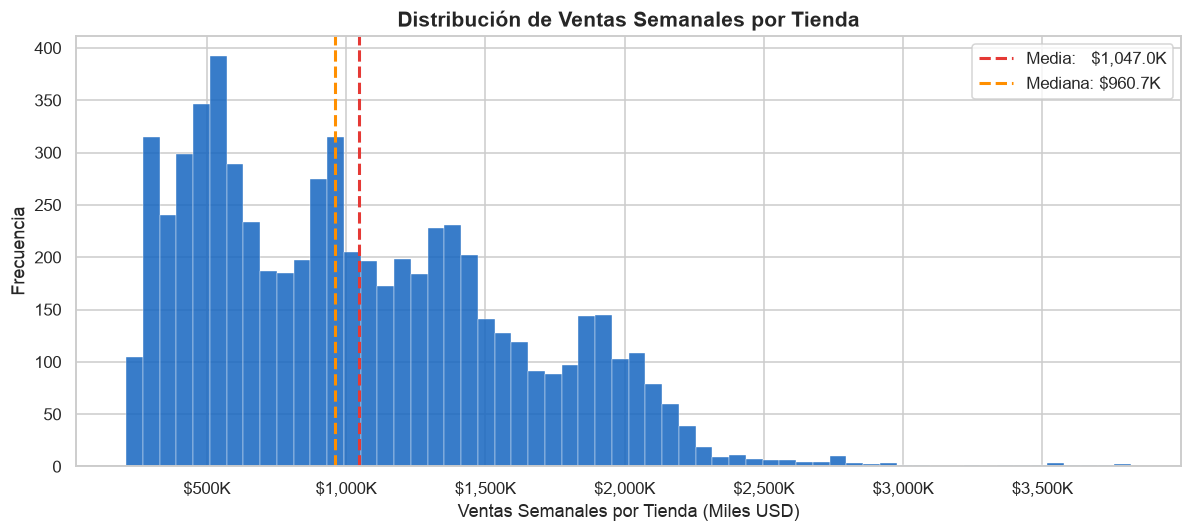

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(df['Weekly_Sales'] / 1e3, bins=60,
        color='#1565C0', edgecolor='white', linewidth=0.3, alpha=0.85)

media   = df['Weekly_Sales'].mean() / 1e3
mediana = df['Weekly_Sales'].median() / 1e3
ax.axvline(media,   color='#E53935', linestyle='--', lw=2, label=f'Media:   ${media:,.1f}K')
ax.axvline(mediana, color='#FF8F00', linestyle='--', lw=2, label=f'Mediana: ${mediana:,.1f}K')

ax.set_xlabel('Ventas Semanales por Tienda (Miles USD)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('Distribución de Ventas Semanales por Tienda', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}K'))
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 4.2 Ventas totales por tienda

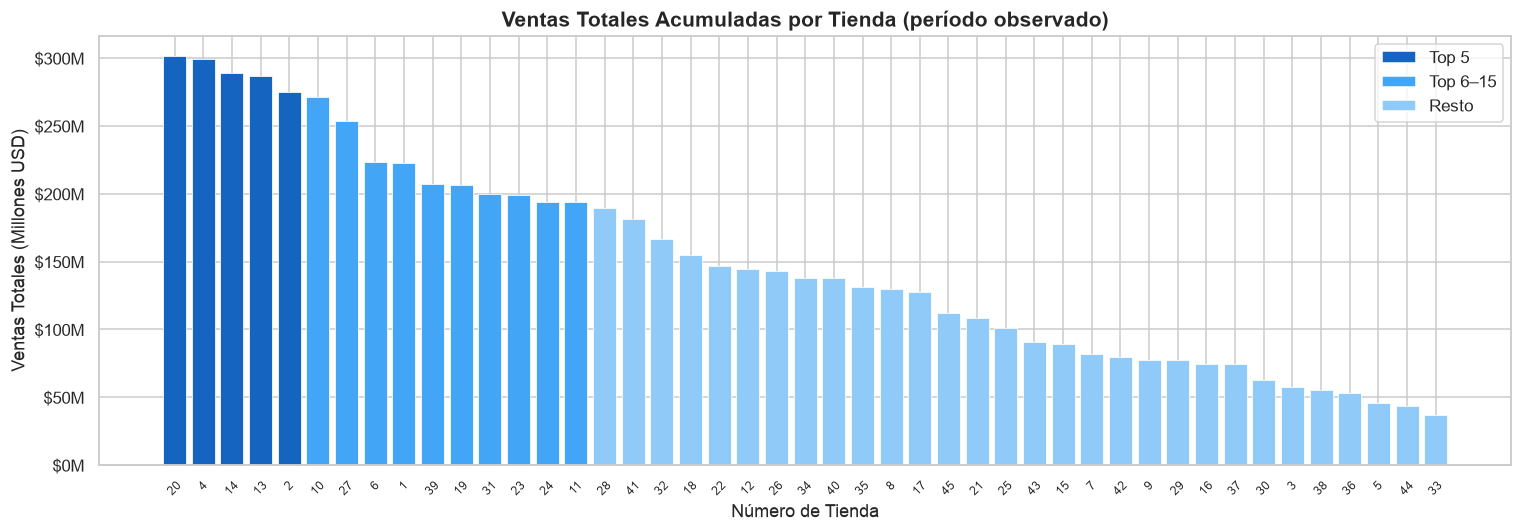

Top 10 tiendas:
 Tienda Millones % del total
     20  $301.4M       4.47%
      4  $299.5M       4.45%
     14  $289.0M       4.29%
     13  $286.5M       4.25%
      2  $275.4M       4.09%
     10  $271.6M       4.03%
     27  $253.9M       3.77%
      6  $223.8M       3.32%
      1  $222.4M       3.30%
     39  $207.4M       3.08%


In [9]:
from matplotlib.patches import Patch

store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#1565C0' if i < 5 else ('#42A5F5' if i < 15 else '#90CAF9')
          for i in range(len(store_sales))]
ax.bar(store_sales.index.astype(str), store_sales.values / 1e6,
       color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Número de Tienda', fontsize=12)
ax.set_ylabel('Ventas Totales (Millones USD)', fontsize=12)
ax.set_title('Ventas Totales Acumuladas por Tienda (período observado)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
plt.xticks(rotation=45, fontsize=8)
ax.legend(handles=[
    Patch(facecolor='#1565C0', label='Top 5'),
    Patch(facecolor='#42A5F5', label='Top 6–15'),
    Patch(facecolor='#90CAF9', label='Resto')
], loc='upper right')
plt.tight_layout()
plt.show()

top10 = store_sales.head(10).reset_index()
top10.columns = ['Tienda','Ventas Totales']
top10['Millones']   = top10['Ventas Totales'].apply(lambda x: f'${x/1e6:.1f}M')
top10['% del total']= (top10['Ventas Totales'] / store_sales.sum() * 100).apply(lambda x: f'{x:.2f}%')
print('Top 10 tiendas:')
print(top10[['Tienda','Millones','% del total']].to_string(index=False))

### 4.3 Evolución temporal de las ventas

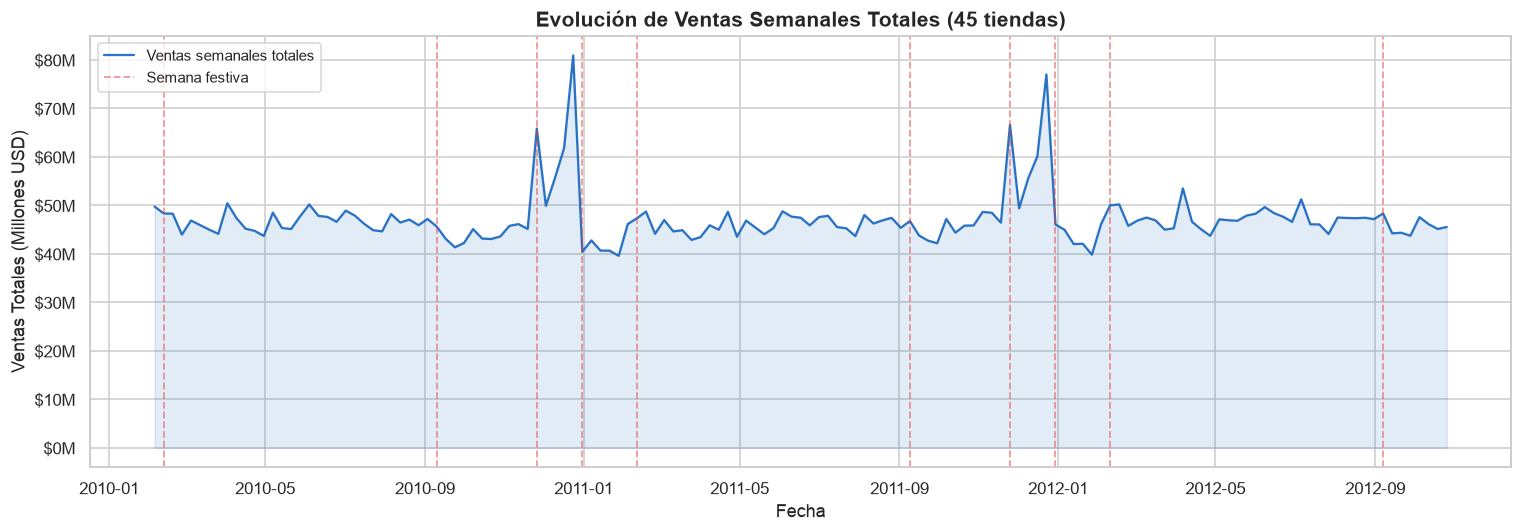

In [10]:
weekly_total  = df.groupby('Date')['Weekly_Sales'].sum() / 1e6
holiday_weeks = df[df['Holiday_Flag'] == 1]['Date'].unique()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekly_total.index, weekly_total.values,
        color='#1565C0', lw=1.5, alpha=0.9, label='Ventas semanales totales')
ax.fill_between(weekly_total.index, weekly_total.values, alpha=0.12, color='#1565C0')

first = True
for hd in holiday_weeks:
    if hd in weekly_total.index:
        ax.axvline(hd, color='#E53935', alpha=0.5, lw=1.2, linestyle='--',
                   label='Semana festiva' if first else '')
        first = False

ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Ventas Totales (Millones USD)', fontsize=12)
ax.set_title('Evolución de Ventas Semanales Totales (45 tiendas)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

### 4.4 Promedio de ventas semanales por mes

Cada observación es una tienda-semana. El gráfico agrupa meses de distintos años; no representa una venta mensual total ni una comparación interanual.

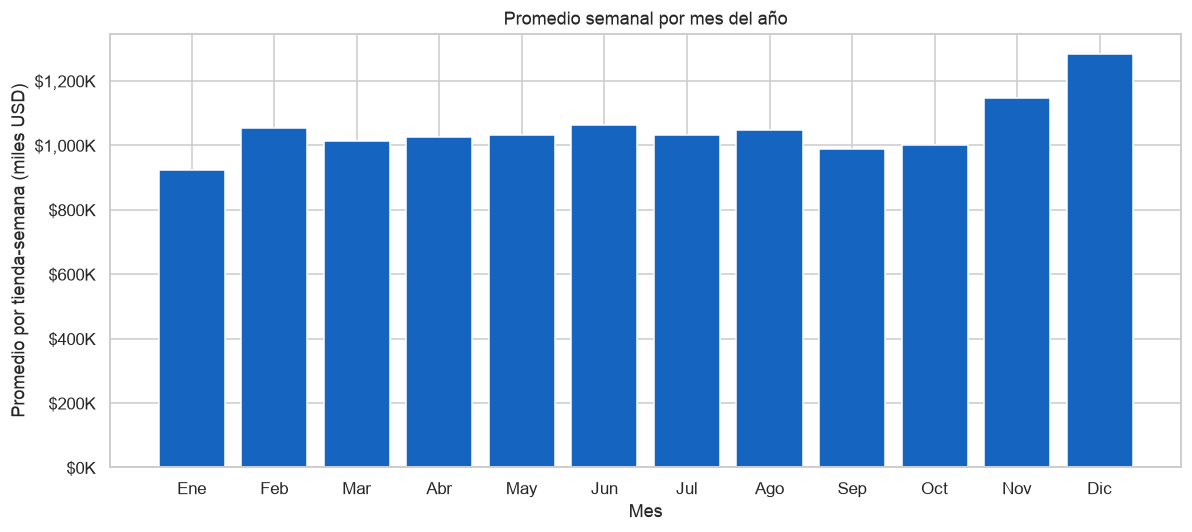

In [11]:
month_es = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
monthly_avg = df.groupby('Month')['Weekly_Sales'].mean().reset_index()
monthly_avg['Mes'] = monthly_avg['Month'].map(month_es)
fig, ax = plt.subplots(figsize=(11,5))
ax.bar(monthly_avg['Mes'], monthly_avg['Weekly_Sales']/1e3, color='#1565C0')
ax.set(xlabel='Mes', ylabel='Promedio por tienda-semana (miles USD)', title='Promedio semanal por mes del año')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}K'))
plt.tight_layout()
plt.show()

### 4.5 Cobertura por año

2010 y 2012 son períodos parciales. Se muestran tanto el total observado como el promedio por tienda-semana; no se interpreta la diferencia de totales como crecimiento anual.

,inicio,fin,semanas,registros,ventas,promedio_semanal
Year,,,,,,
2010,2010-02-05,2010-12-31,48,2160,2.288886e+09,1.059670e+06
2011,2011-01-07,2011-12-30,52,2340,2.448200e+09,1.046239e+06
2012,2012-01-06,2012-10-26,43,1935,2.000133e+09,1.033660e+06


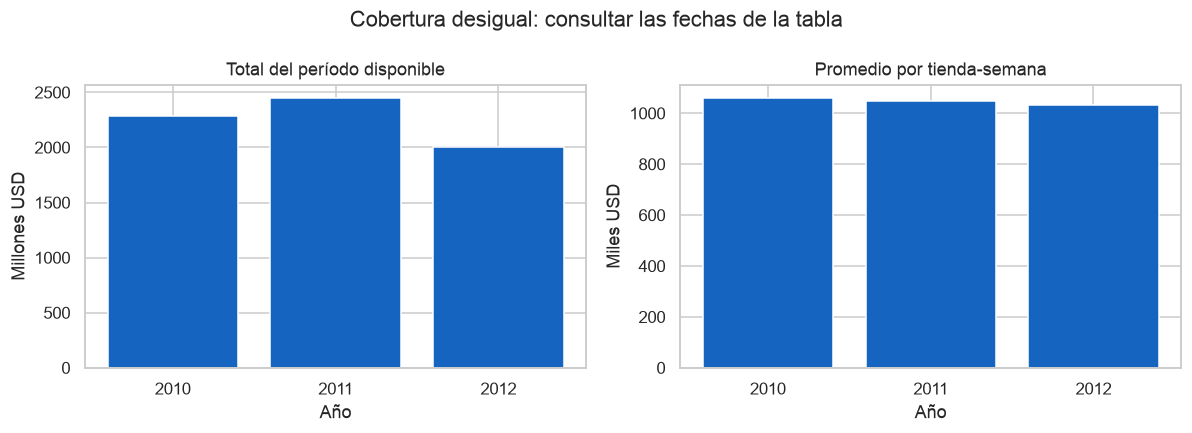

In [12]:
yearly = df.groupby('Year').agg(inicio=('Date','min'), fin=('Date','max'), semanas=('Date','nunique'), registros=('Weekly_Sales','size'), ventas=('Weekly_Sales','sum'), promedio_semanal=('Weekly_Sales','mean'))
display(yearly)
fig, axes = plt.subplots(1,2,figsize=(11,4))
axes[0].bar(yearly.index.astype(str),yearly['ventas']/1e6,color='#1565C0')
axes[0].set(title='Total del período disponible',ylabel='Millones USD',xlabel='Año')
axes[1].bar(yearly.index.astype(str),yearly['promedio_semanal']/1e3,color='#1565C0')
axes[1].set(title='Promedio por tienda-semana',ylabel='Miles USD',xlabel='Año')
fig.suptitle('Cobertura desigual: consultar las fechas de la tabla')
plt.tight_layout()
plt.show()

### 4.6 Semanas festivas vs. no festivas

In [13]:
stats_h = df.groupby('Holiday_Label')['Weekly_Sales'].agg(['mean','median','std','count'])
stats_h.columns = ['Media','Mediana','Desv. Est.','Registros']
print(stats_h.round(0))

mean_f  = stats_h.loc['Festiva',    'Media']
mean_nf = stats_h.loc['No Festiva', 'Media']
print(f'\nDiferencia descriptiva festivas / no festivas: {(mean_f/mean_nf - 1)*100:.1f}%')

                   Media    Mediana  Desv. Est.  Registros
Holiday_Label                                             
Festiva        1122888.0  1018538.0    627685.0        450
No Festiva     1041256.0   956211.0    558957.0       5985

Diferencia descriptiva festivas / no festivas: 7.8%


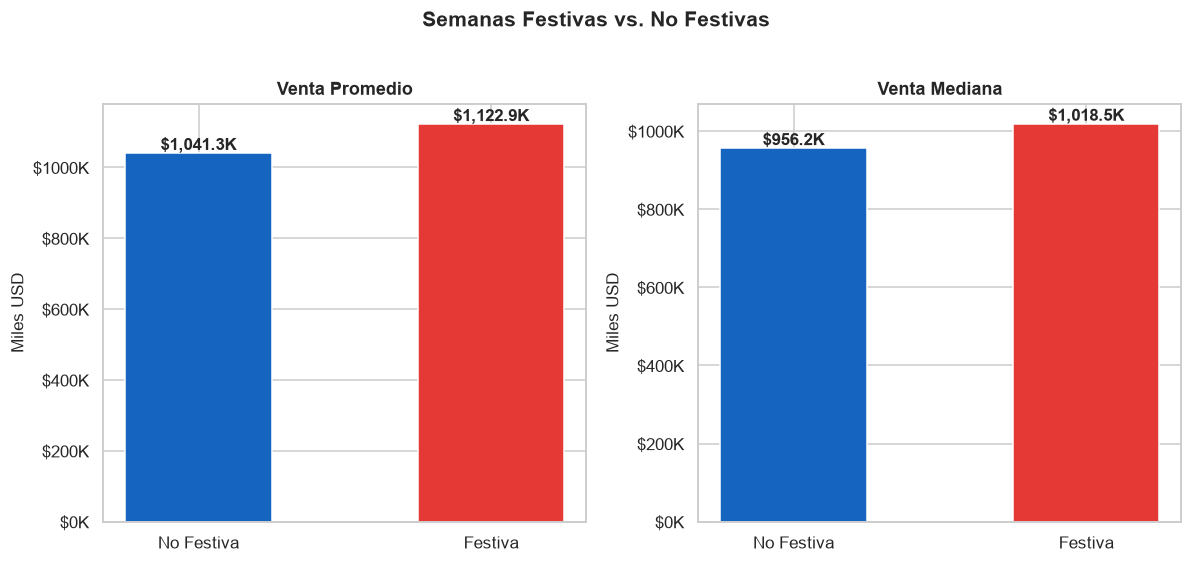

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
labels_h = ['No Festiva', 'Festiva']
colors_h = ['#1565C0', '#E53935']

vals_mean = [stats_h.loc['No Festiva','Media']/1e3,  stats_h.loc['Festiva','Media']/1e3]
vals_med  = [stats_h.loc['No Festiva','Mediana']/1e3, stats_h.loc['Festiva','Mediana']/1e3]

for ax, vals, titulo in zip(axes, [vals_mean, vals_med], ['Venta Promedio', 'Venta Mediana']):
    bars = ax.bar(labels_h, vals, color=colors_h, edgecolor='white', width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 8,
                f'${v:,.1f}K', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylabel('Miles USD', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))

plt.suptitle('Semanas Festivas vs. No Festivas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.7 Mapa de calor de correlaciones

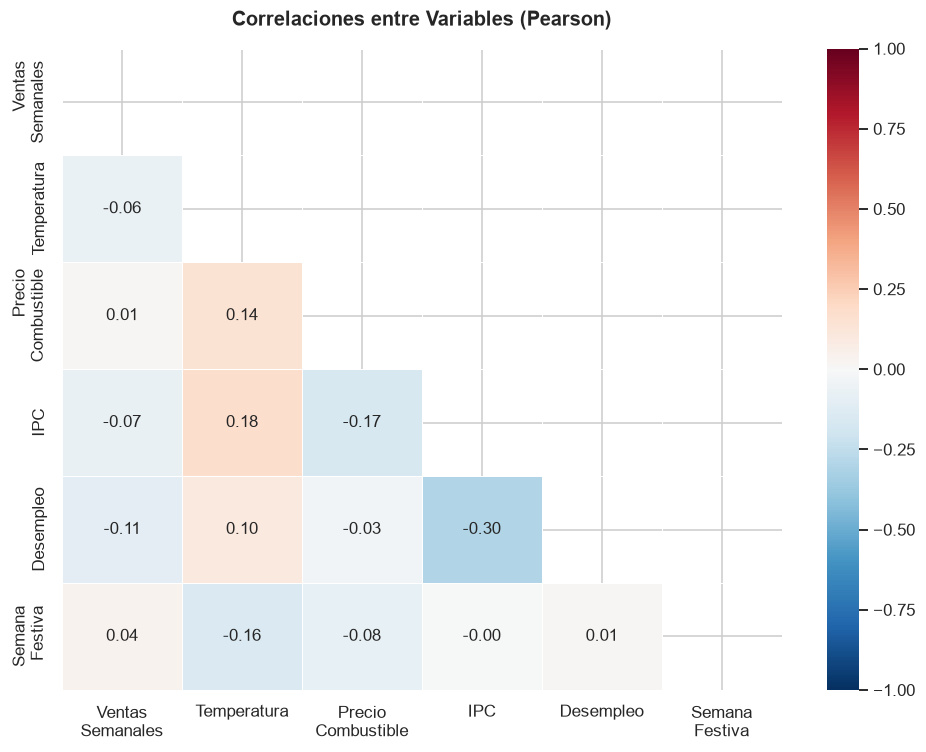

Correlación con Ventas Semanales:
  Holiday_Flag         r = +0.0369
  Fuel_Price           r = +0.0095
  Temperature          r = -0.0638
  CPI                  r = -0.0726
  Unemployment         r = -0.1062


In [15]:
corr_cols  = ['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment','Holiday_Flag']
labels_map = {'Weekly_Sales':'Ventas\nSemanales','Temperature':'Temperatura',
              'Fuel_Price':'Precio\nCombustible','CPI':'IPC',
              'Unemployment':'Desempleo','Holiday_Flag':'Semana\nFestiva'}

corr_m = df[corr_cols].corr()
corr_m.index   = [labels_map[c] for c in corr_m.index]
corr_m.columns = [labels_map[c] for c in corr_m.columns]

mask = np.triu(np.ones_like(corr_m, dtype=bool))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_m, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, linecolor='white', vmin=-1, vmax=1,
            annot_kws={'size': 11})
ax.set_title('Correlaciones entre Variables (Pearson)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('Correlación con Ventas Semanales:')
corr_v = df[corr_cols].corr()['Weekly_Sales'].drop('Weekly_Sales').sort_values(ascending=False)
for var, val in corr_v.items():
    print(f'  {var:<20} r = {val:+.4f}')

### 4.8 Diagramas de dispersión: ventas vs variables del entorno

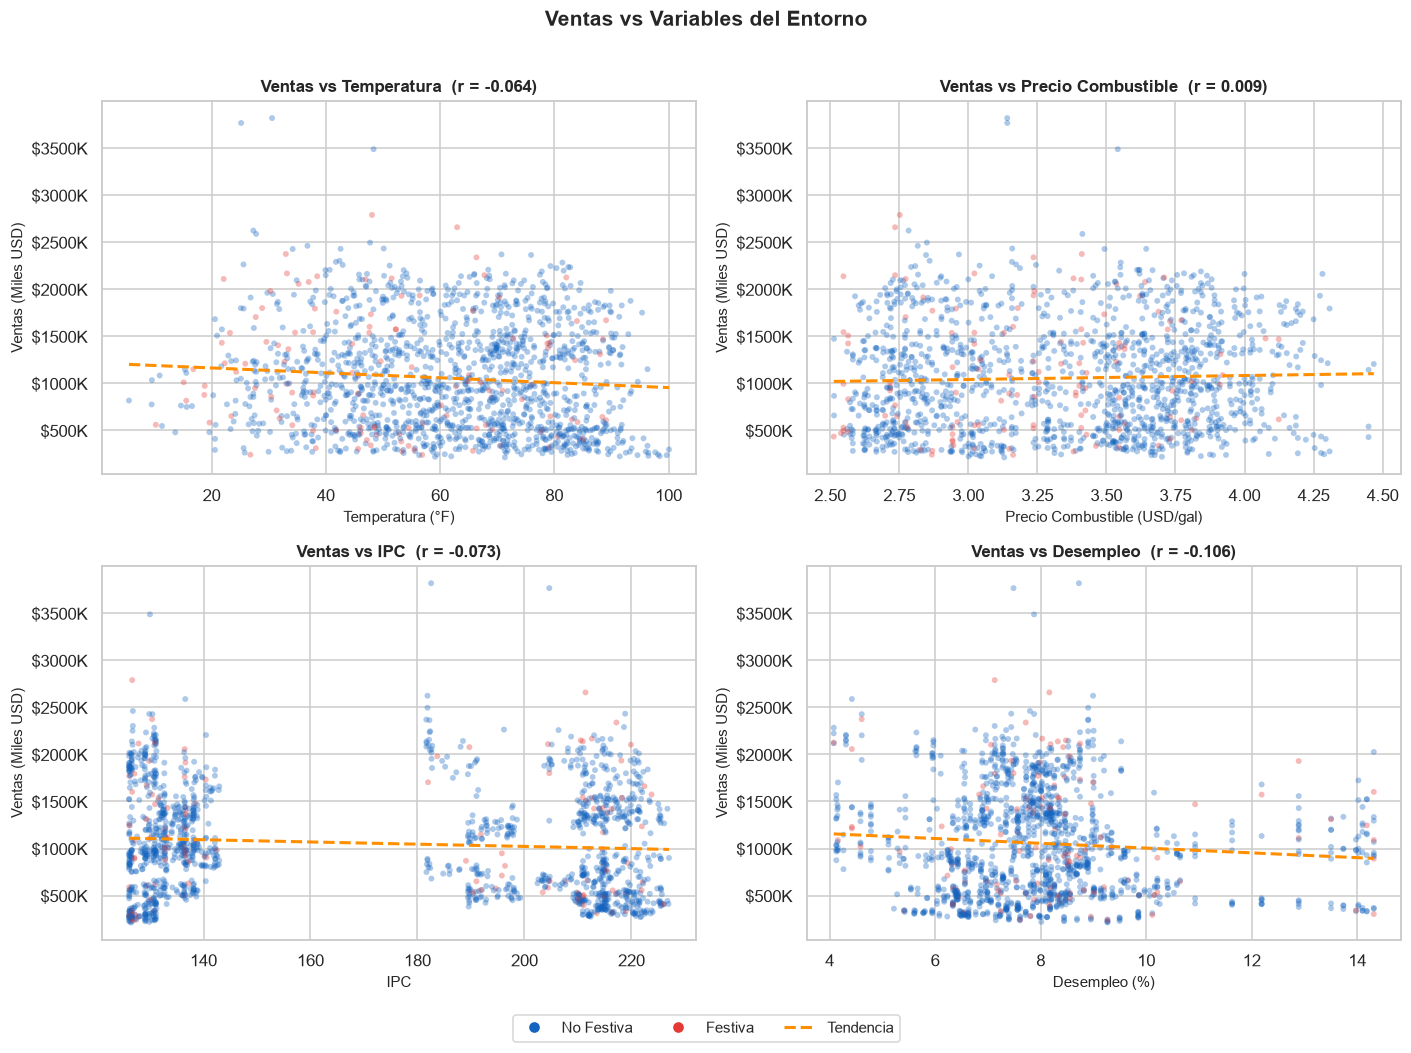

In [16]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
variables = ['Temperature','Fuel_Price','CPI','Unemployment']
etiquetas = ['Temperatura (°F)','Precio Combustible (USD/gal)','IPC','Desempleo (%)']
sample = df.sample(n=min(1500, len(df)), random_state=42)

for ax, var, label in zip(axes.flat, variables, etiquetas):
    c_pts = sample['Holiday_Flag'].map({0:'#1565C0', 1:'#E53935'})
    ax.scatter(sample[var], sample['Weekly_Sales']/1e3,
               c=c_pts, alpha=0.35, s=15, edgecolors='none')
    z = np.polyfit(sample[var], sample['Weekly_Sales']/1e3, 1)
    xline = np.linspace(sample[var].min(), sample[var].max(), 100)
    ax.plot(xline, np.poly1d(z)(xline), color='#FF8F00', lw=2, linestyle='--')
    r = df[var].corr(df['Weekly_Sales'])
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Ventas (Miles USD)', fontsize=10)
    ax.set_title(f'Ventas vs {label.split(" (")[0]}  (r = {r:.3f})', fontsize=11, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))

fig.legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#1565C0', ms=8, label='No Festiva'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#E53935',  ms=8, label='Festiva'),
    Line2D([0],[0], color='#FF8F00', lw=2, linestyle='--', label='Tendencia')
], loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.04))
plt.suptitle('Ventas vs Variables del Entorno', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.9 Distribución de ventas por trimestre

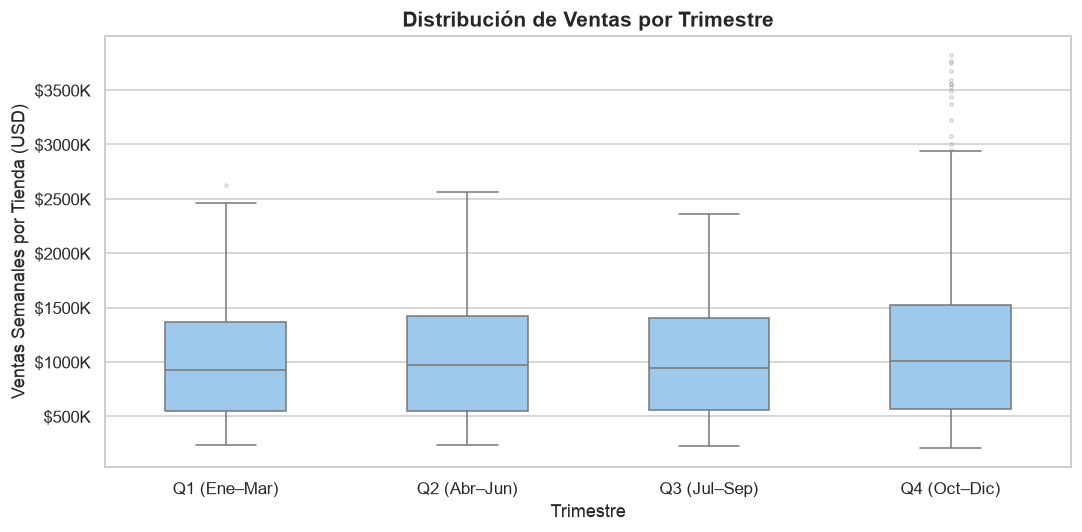

                   Media     Mediana
Q1 (Ene–Mar)  $1,006,136    $922,898
Q2 (Abr–Jun)  $1,040,806    $972,664
Q3 (Jul–Sep)  $1,023,251    $946,883
Q4 (Oct–Dic)  $1,128,774  $1,005,449


In [17]:
q_labels = {1:'Q1 (Ene–Mar)', 2:'Q2 (Abr–Jun)', 3:'Q3 (Jul–Sep)', 4:'Q4 (Oct–Dic)'}
df['Quarter_Label'] = df['Quarter'].map(q_labels)
order = list(q_labels.values())

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='Quarter_Label', y='Weekly_Sales', order=order,
            color='#90CAF9', ax=ax,
            width=0.5, flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_xlabel('Trimestre', fontsize=12)
ax.set_ylabel('Ventas Semanales por Tienda (USD)', fontsize=12)
ax.set_title('Distribución de Ventas por Trimestre', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

q_stats = df.groupby('Quarter')['Weekly_Sales'].agg(['mean','median']).round(0)
q_stats.index = order
q_stats.columns = ['Media','Mediana']
print(q_stats.map(lambda x: f'${x:,.0f}').to_string())

## Resultados principales

In [18]:
top_store = int(store_sales.index[0])
top_share = store_sales.head(10).sum()/store_sales.sum()
holiday_difference = (mean_f/mean_nf-1)*100
display(Markdown(f"""
- La muestra contiene **{len(df):,} registros**, **{df.Store.nunique()} tiendas** y **{df.Date.nunique()} semanas**.
- La tienda **{top_store}** acumula el mayor volumen del período. Las diez primeras reúnen el **{top_share:.1%}** de las ventas de la muestra.
- Las semanas marcadas como festivas registran una media **{holiday_difference:.1f}%** superior a las no festivas. Es una asociación descriptiva, no una estimación del efecto de un feriado.
- La cobertura temporal cambia entre años. Los totales anuales incompletos no permiten calcular directamente una tasa de crecimiento comparable.
"""))


- La muestra contiene **6,435 registros**, **45 tiendas** y **143 semanas**.
- La tienda **20** acumula el mayor volumen del período. Las diez primeras reúnen el **39.1%** de las ventas de la muestra.
- Las semanas marcadas como festivas registran una media **7.8%** superior a las no festivas. Es una asociación descriptiva, no una estimación del efecto de un feriado.
- La cobertura temporal cambia entre años. Los totales anuales incompletos no permiten calcular directamente una tasa de crecimiento comparable.


## Conclusión

El análisis permite comparar tiendas y reconocer períodos de mayor venta dentro de la muestra. Para planificar inventario convendría complementar estas observaciones con ventas por producto, existencias y costos. Las correlaciones agregadas no explican por sí solas las diferencias entre tiendas. La ausencia de nulos y duplicados no descarta todos los posibles errores de origen; los valores extremos se mantienen porque el archivo no ofrece evidencia suficiente para corregirlos.